In [1]:
from analytics_queries import DashboardQueries
dq = DashboardQueries()

import pandas as pd

In [2]:
df_season = pd.DataFrame(dq.seasonal_pm25_profile())

In [3]:
df_aqi = pd.DataFrame(dq.monthly_avg_aqi_mom())

In [ ]:
print("\n=== Seasonal PM2.5 profile (ranked) ===")
display(df_season)


=== Seasonal PM2.5 profile (ranked) ===


,city,season,season_order,avg_pm25,season_rank
0,Cairo,Winter,1,116.36,1
1,Cairo,Summer,3,124.08,2
2,Cairo,Spring,2,126.17,3
3,Cairo,Autumn,4,131.81,4
4,Delhi,Autumn,4,114.16,1
5,Delhi,Spring,2,119.60,2
6,Delhi,Winter,1,121.57,3
7,Delhi,Summer,3,132.47,4
8,Los Angeles,Winter,1,125.97,1
9,Los Angeles,Spring,2,128.71,2


In [5]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
df_season["season"] = pd.Categorical(df_season["season"], SEASON_ORDER, ordered=True)

def available_cities(df):
    return sorted(df["city"].dropna().unique().tolist())
print("Cities:", available_cities(df_season))


Cities: ['Cairo', 'Delhi', 'Los Angeles', 'New York', 'Paris', 'São Paulo']


/tmp/ipykernel_25937/3343437418.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = (data.pivot_table(index="season", columns="city", values="avg_pm25")


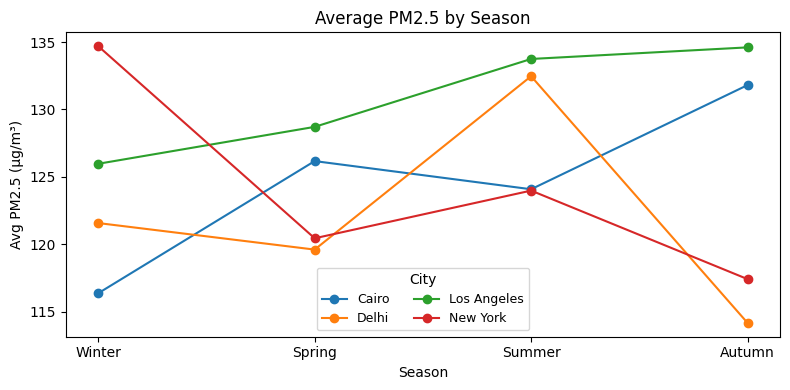

In [ ]:
def plot_pm25_season_profile_multi(df_season, cities=None):
    data = df_season if not cities else df_season[df_season["city"].isin(cities)]
    pivot = (data.pivot_table(index="season", columns="city", values="avg_pm25")
                  .reindex(SEASON_ORDER))
    if pivot.empty:
        print("No data for selected cities"); return

    plt.figure(figsize=(8,4))
    for col in pivot.columns:
        plt.plot(pivot.index.astype(str), pivot[col], marker="o", label=col)
    plt.title("Average PM2.5 by Season")
    plt.xlabel("Season"); plt.ylabel("Avg PM2.5 (µg/m³)")
    plt.legend(title="City", fontsize=9, ncols=2)
    plt.tight_layout(); plt.show()

plot_pm25_season_profile_multi(df_season, cities=["Cairo","Delhi","Los Angeles","New York"])


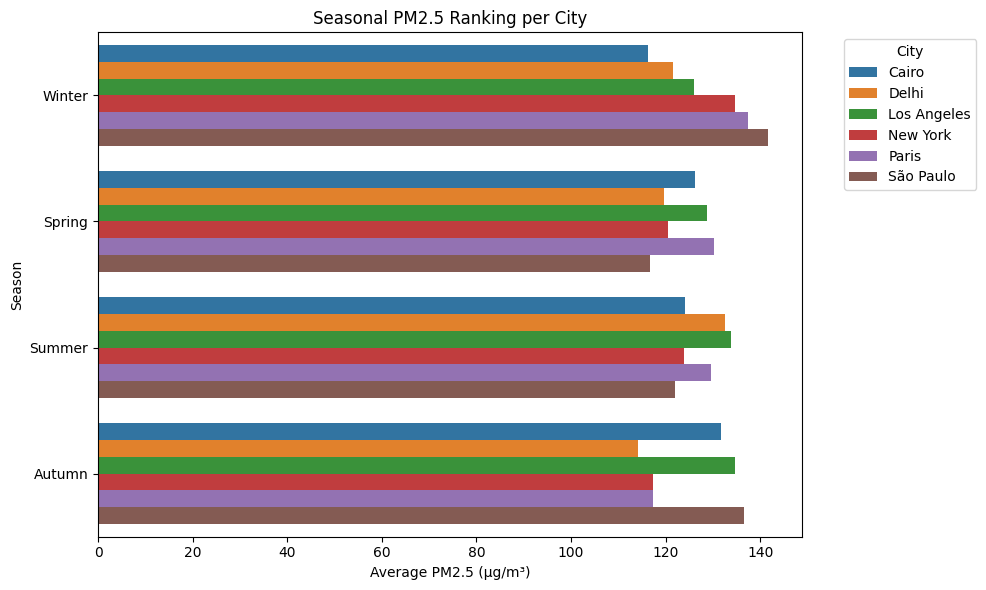

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

season_order = ["Winter", "Spring", "Summer", "Autumn"]
df_season["season"] = pd.Categorical(df_season["season"], categories=season_order, ordered=True)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_season,
    x="avg_pm25", 
    y="season", 
    hue="city", 
    orient="h"
)

plt.title("Seasonal PM2.5 Ranking per City")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.ylabel("Season")
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [ ]:
print("\n=== Monthly Average AQI (with MoM change) ===")
display(df_aqi)


=== Monthly Average AQI (with MoM change) ===


,city,month,avg_aqi,mom_change_aqi
0,Cairo,2024-01-01,184.52,0.07
1,Cairo,2024-02-01,184.45,24.58
2,Cairo,2024-03-01,159.87,21.24
3,Cairo,2024-04-01,138.63,7.18
4,Cairo,2024-05-01,131.45,-49.55
...,...,...,...,...
67,São Paulo,2024-08-01,174.52,18.12
68,São Paulo,2024-09-01,156.40,-12.12
69,São Paulo,2024-10-01,168.52,0.59
70,São Paulo,2024-11-01,167.93,-16.81


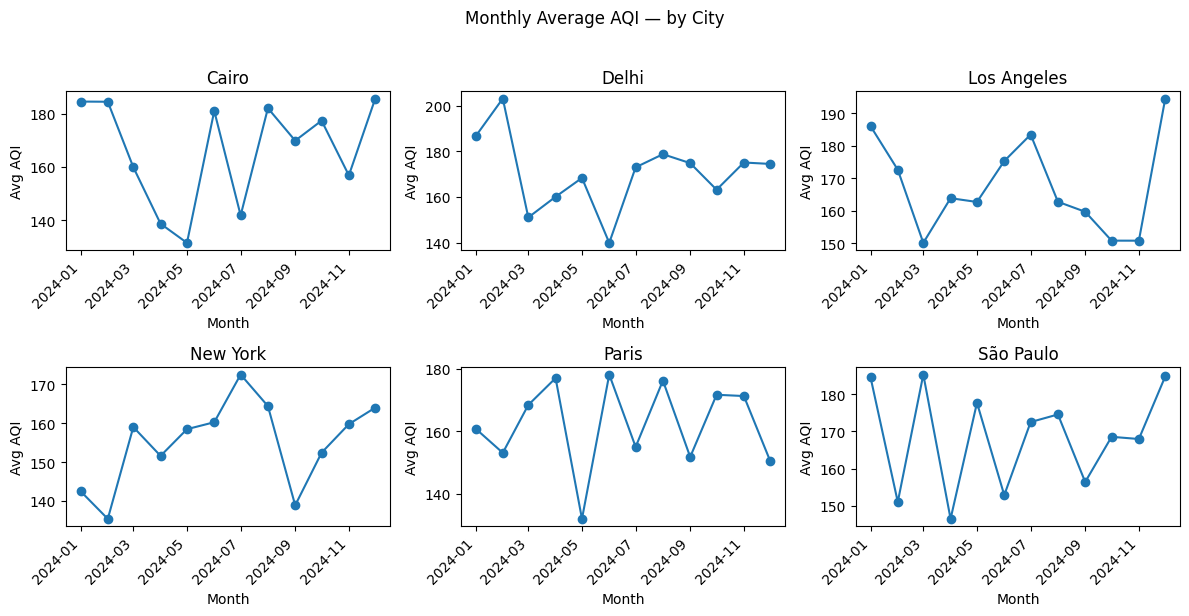

In [ ]:
import math

def plot_monthly_aqi_small_multiples(df_aqi, cities=None, ncols=3, height_per_row=3.0):
    """
    One mini-plot per city. Use `cities` to order/filter if desired.
    """
    if cities is None:
        cities = sorted(df_aqi["city"].dropna().unique().tolist())

    n = len(cities)
    if n == 0:
        print("No cities found."); 
        return

    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, height_per_row*nrows), squeeze=False)

    for i, city in enumerate(cities):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        d = (df_aqi[df_aqi["city"] == city]
                .sort_values("month")
                .reset_index(drop=True))
        if d.empty:
            ax.set_visible(False); 
            continue
        ax.plot(d["month"], d["avg_aqi"], marker="o")
        ax.set_title(city)
        ax.set_xlabel("Month"); ax.set_ylabel("Avg AQI")
        for label in ax.get_xticklabels():
            label.set_rotation(45); label.set_horizontalalignment("right")

    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].set_visible(False)

    fig.suptitle("Monthly Average AQI — by City", y=1.02)
    fig.tight_layout()
    plt.show()

plot_monthly_aqi_small_multiples(df_aqi, ncols=3)


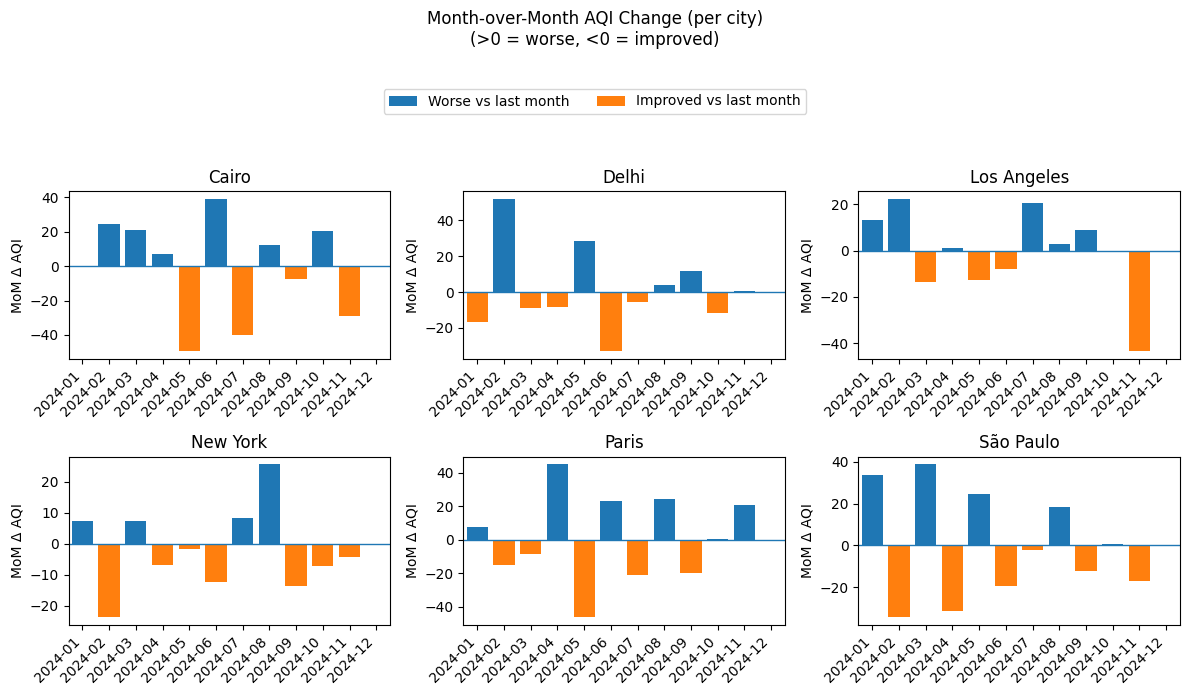

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

def plot_mom_change_small_multiples(df_aqi, cities=None, ncols=3, height_per_row=3.0):
    if cities is None:
        cities = sorted(df_aqi["city"].dropna().unique().tolist())
    n = len(cities)
    if n == 0:
        print("No cities found."); return

    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, height_per_row*nrows), squeeze=False)

    for i, city in enumerate(cities):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        d = (df_aqi[df_aqi["city"] == city]
             .sort_values("month")
             .reset_index(drop=True))

        x = np.arange(len(d))
        y = d["mom_change_aqi"].fillna(0.0)

        ax.bar(x[y>=0], y[y>=0], label="Worse vs last month")
        ax.bar(x[y<0],  y[y<0],  label="Improved vs last month")

        ax.set_xticks(x)
        ax.set_xticklabels(d["month"].dt.strftime("%Y-%m"), rotation=45, ha="right")
        ax.axhline(0, linewidth=1)

        ax.set_title(city)
        ax.set_ylabel("MoM Δ AQI")
        ax.margins(x=0.01)

    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].set_visible(False)

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle("Month-over-Month AQI Change (per city)\n(>0 = worse, <0 = improved)", y=1.15)
    fig.tight_layout()
    plt.show()

plot_mom_change_small_multiples(df_aqi, ncols=3)
